In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kuldeepjangra/customer-behavior-and-churn-prediction-dataset/medium_churn_dataset_100k.csv


# Introduction

Customer churn is a critical problem for businesses. In this notebook, we build a complete ML pipeline:
- Data Cleaning & Preprocessing
- Feature Engineering
- Handling Imbalance
- Advanced Models (XGBoost, LightGBM)
- Ensemble Learning
- SHAP Explainability
- Business Insights

# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedGroupKFold,StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')
import optuna

# Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/kuldeepjangra/customer-behavior-and-churn-prediction-dataset/medium_churn_dataset_100k.csv')
df.head()

,customer_id,age,gender,city,tenure_months,monthly_spend,total_orders,app_usage_time,days_since_last_login,cart_abandon_rate,support_tickets,discount_usage,payment_method,churn
0,200000,56,Female,Pune,37,4303.0,73,202.0,264,0.65,25,0.15,UPI,0
1,200001,69,Female,Kolkata,5,4239.0,250,214.0,265,0.39,16,0.61,Card,0
2,200002,46,Male,Hyderabad,62,16867.0,300,85.0,191,0.39,11,0.59,NetBanking,1
3,200003,32,Male,Hyderabad,31,17641.0,306,253.0,28,0.39,9,0.08,UPI,0
4,200004,60,Male,Pune,107,12655.0,125,186.0,341,0.34,2,0.20,COD,0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  int64  
 1   age                    100000 non-null  int64  
 2   gender                 100000 non-null  object 
 3   city                   100000 non-null  object 
 4   tenure_months          100000 non-null  int64  
 5   monthly_spend          95000 non-null   float64
 6   total_orders           100000 non-null  int64  
 7   app_usage_time         95000 non-null   float64
 8   days_since_last_login  100000 non-null  int64  
 9   cart_abandon_rate      100000 non-null  float64
 10  support_tickets        100000 non-null  int64  
 11  discount_usage         95000 non-null   float64
 12  payment_method         100000 non-null  object 
 13  churn                  100000 non-null  int64  
dtypes: float64(4), int64(7), object(3)
me

,customer_id,age,tenure_months,monthly_spend,total_orders,app_usage_time,days_since_last_login,cart_abandon_rate,support_tickets,discount_usage,churn
count,100000.000000,100000.000000,100000.000000,95000.000000,100000.000000,95000.000000,100000.000000,100000.000000,100000.000000,95000.000000,100000.000000
mean,249999.500000,43.500270,60.157810,10228.809947,200.247480,151.967979,182.279320,0.500186,14.484110,0.500161,0.397950
std,28867.657797,14.970933,34.351438,5632.565120,114.953129,85.390476,105.339031,0.289065,8.646585,0.289004,0.489477
min,200000.000000,18.000000,1.000000,500.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,224999.750000,31.000000,30.000000,5333.000000,101.000000,78.000000,91.000000,0.250000,7.000000,0.250000,0.000000
50%,249999.500000,43.000000,60.000000,10224.000000,200.000000,152.000000,182.000000,0.500000,14.000000,0.500000,0.000000
75%,274999.250000,56.000000,90.000000,15131.000000,299.000000,226.000000,274.000000,0.750000,22.000000,0.750000,1.000000
max,299999.000000,69.000000,119.000000,19999.000000,399.000000,299.000000,364.000000,1.000000,29.000000,1.000000,1.000000


# Data cleaning

In [5]:
# check missing values
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
city                        0
tenure_months               0
monthly_spend            5000
total_orders                0
app_usage_time           5000
days_since_last_login       0
cart_abandon_rate           0
support_tickets             0
discount_usage           5000
payment_method              0
churn                       0
dtype: int64

In [6]:
df.fillna(method = 'ffill',inplace=True)

In [7]:
# Drop unnecessary columns
df.drop('customer_id',axis=1,inplace=True)

In [8]:
# Remove duplicates
df.drop_duplicates(inplace = True)

# Encoding Categorical Variables

In [9]:
cat_cols = ['gender','city','payment_method']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Feature Engineering

In [10]:
df['avg_order_value'] = df['monthly_spend']/(df['total_orders']+1)
df['engagement_score'] = df['app_usage_time']/(df['days_since_last_login']+1)
df['support_intensity'] = df['support_tickets']/(df['tenure_months']+1)
df['discount_ratio'] = df['discount_usage']/df['total_orders']

# Train-Test Split

In [11]:
X= df.drop('churn',axis =1)
y = df['churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Feature Scaling

In [12]:
scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Handle Class Imbalance

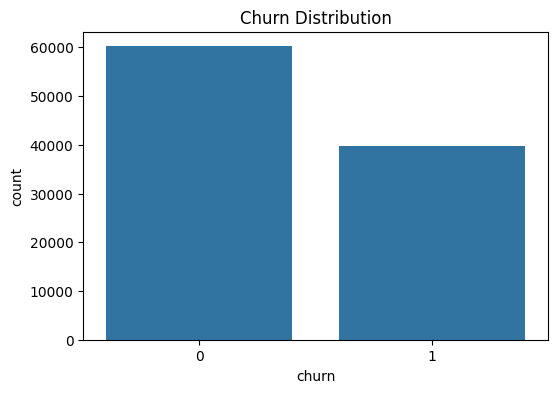

churn
0    0.60205
1    0.39795
Name: proportion, dtype: float64


In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()

print(y.value_counts(normalize=True))

In [14]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train,y_train)

# Model Training


**1. XGBoost**

In [15]:
xgb = XGBClassifier(
    n_estimators = 300,
    max_depth = 6,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_sm,y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

**LightGBM**

In [16]:
lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
lgb.fit(X_train_sm,y_train_sm)

[LightGBM] [Info] Number of positive: 41949, number of negative: 41949
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3855
[LightGBM] [Info] Number of data points in the train set: 83898, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42)

**Random Forest**

In [17]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train_sm,y_train_sm)

RandomForestClassifier(n_estimators=200, random_state=42)

# Model Evaluation

In [18]:
models = {
    "XGBoost":xgb,
    "LightGBM":lgb,
    "RandomForest":rf
}
for name,model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    print(f"{name} ROC-AUC:",roc_auc_score(y_test,y_pred_proba))

XGBoost ROC-AUC: 0.6927456439240162
LightGBM ROC-AUC: 0.6947768011994713
RandomForest ROC-AUC: 0.6793631226761027


# Ensemble Model

In [19]:
ensemble = VotingClassifier(
    estimators=[
        ('xgb',xgb),
        ('lgb',lgb),
        ('rf',rf)
    ],
    voting='soft'
)

ensemble.fit(X_train_sm,y_train_sm)

y_pred_proba = ensemble.predict_proba(X_test)[:,1]
print("Ensemble ROC-AUC:",roc_auc_score(y_test,y_pred_proba))

[LightGBM] [Info] Number of positive: 41949, number of negative: 41949
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3855
[LightGBM] [Info] Number of data points in the train set: 83898, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Ensemble ROC-AUC: 0.6929333178431726


# Confusion Matrix

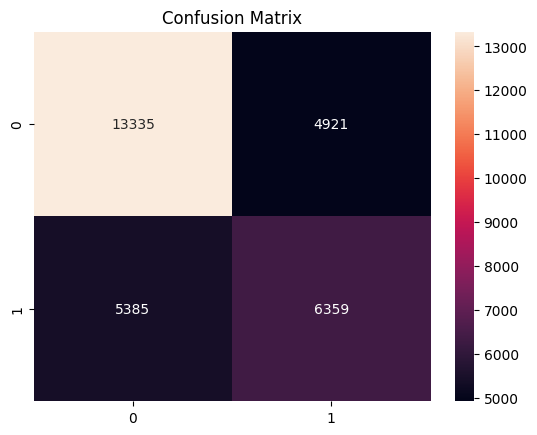

In [20]:
y_pred = ensemble.predict(X_test)
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

# SHAP Explanaibility

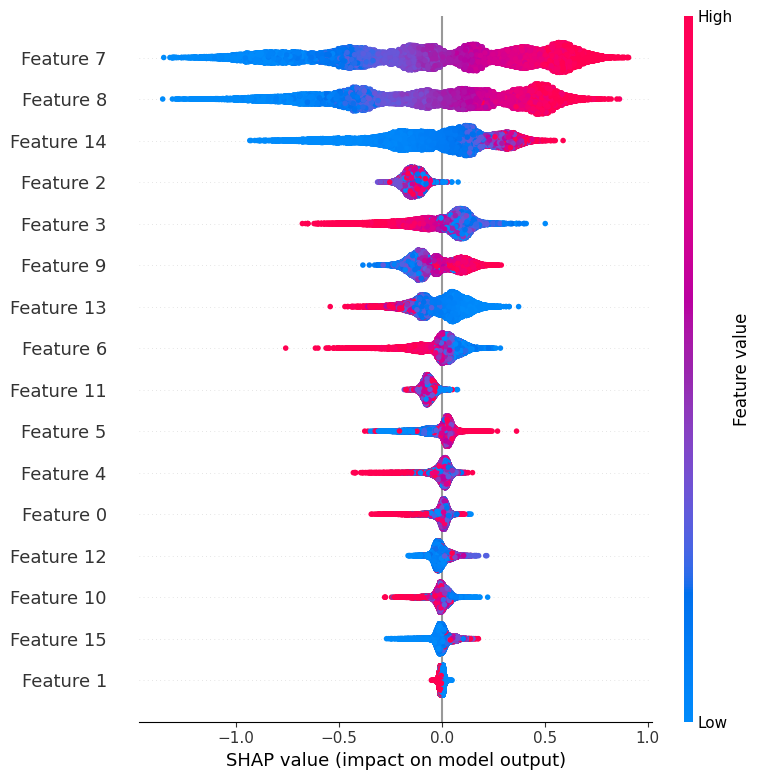

In [21]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.summary_plot(shap_values,X_test)

# Feature Importance

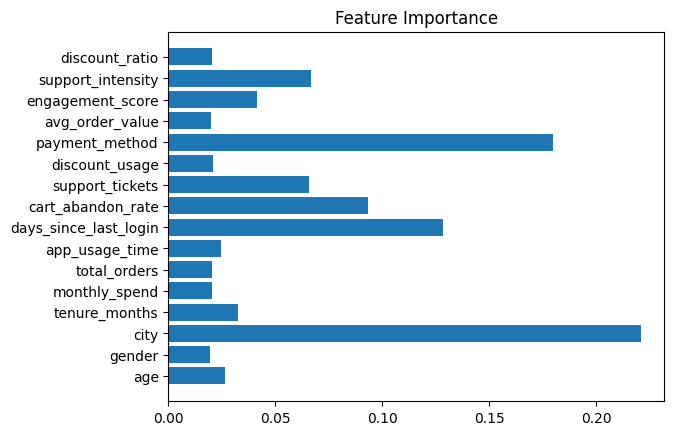

In [22]:
importances = xgb.feature_importances_
features = df.drop('churn',axis=1).columns

plt.barh(features,importances)
plt.title("Feature Importance")
plt.show()

# Stratified K-Fold Cross Validation

In [23]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
xgb_scores = []
for fold, (train_idx,val_idx) in enumerate(skf.split(X,y)):
    X_train_fold, X_val_fold = X.iloc[train_idx],X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx],y.iloc[val_idx]

    # Scaling
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold,y_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    # SMOTE
    sm = SMOTE(random_state=42)
    X_train_fold,y_train_fold = sm.fit_resample(X_train_fold,y_train_fold)

    model = XGBClassifier(
        n_estimators = 300,
        max_depth = 6,
        learning_rate = 0.05,
        random_state  = 42
    )

    model.fit(X_train_fold,y_train_fold)

    preds = model.predict_proba(X_val_fold)[:,1]
    score = roc_auc_score(y_val_fold,preds)

    xgb_scores.append(score)

    print(f"Fold{fold+1} ROC-AUC:",score)

print("Mean ROC-AUC:",np.mean(xgb_scores))

Fold1 ROC-AUC: 0.6920084390645067
Fold2 ROC-AUC: 0.6911104152573986
Fold3 ROC-AUC: 0.6849075329684349
Fold4 ROC-AUC: 0.6977636320450089
Fold5 ROC-AUC: 0.6894781711758186
Mean ROC-AUC: 0.6910536381022335


# Optuna Hyperparamter Tuning

In [24]:
def objective(trial):
    params = {
        "n_estimators":trial.suggest_int("n_estimators",200,500),
        "max_depth":trial.suggest_int("max_depth",3,10),
        "learning_rate":trial.suggest_float("learning_rate",0.01,0.1),
        "subsample":trial.suggest_float("subsample",0.6,1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree",0.6,1.0),
        "gamma":trial.suggest_float('gamma',0,5)
    }

    model = XGBClassifier(**params,random_state=42)
    model.fit(X_train_sm,y_train_sm)
    preds = model.predict_proba(X_test)[:,1]
    return roc_auc_score(y_test,preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=20)

print("Best Params:",study.best_params)

[I 2026-05-14 17:13:14,823] A new study created in memory with name: no-name-485a3186-75b2-4710-9bed-e2a04af3b453
[I 2026-05-14 17:13:16,902] Trial 0 finished with value: 0.6873008241327699 and parameters: {'n_estimators': 343, 'max_depth': 7, 'learning_rate': 0.07528879815053162, 'subsample': 0.8826159711941107, 'colsample_bytree': 0.6414200569379073, 'gamma': 1.5939538316608974}. Best is trial 0 with value: 0.6873008241327699.
[I 2026-05-14 17:13:18,782] Trial 1 finished with value: 0.6879421393615954 and parameters: {'n_estimators': 355, 'max_depth': 6, 'learning_rate': 0.08551779712698046, 'subsample': 0.9622262421677739, 'colsample_bytree': 0.8589435369753609, 'gamma': 0.8602326870511773}. Best is trial 1 with value: 0.6879421393615954.
[I 2026-05-14 17:13:20,358] Trial 2 finished with value: 0.6874145213092571 and parameters: {'n_estimators': 255, 'max_depth': 9, 'learning_rate': 0.07682031830643232, 'subsample': 0.913912869357765, 'colsample_bytree': 0.9738873391593486, 'gamma':

Best Params: {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.010113131269575536, 'subsample': 0.7396008005746517, 'colsample_bytree': 0.8057517518939934, 'gamma': 4.216166011853667}


In [25]:
best_xgb = XGBClassifier(**study.best_params)
best_xgb.fit(X_train_sm, y_train_sm)

y_pred = best_xgb.predict_proba(X_test)[:,1]
print("Optimized ROC-AUC:", roc_auc_score(y_test, y_pred))

Optimized ROC-AUC: 0.6964102573981128


# SHAP Dependence Plots

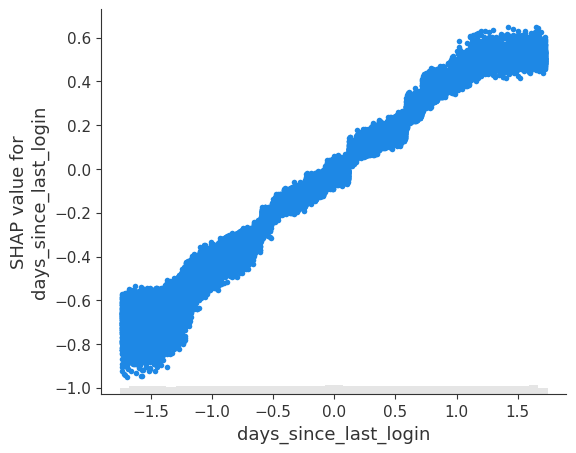

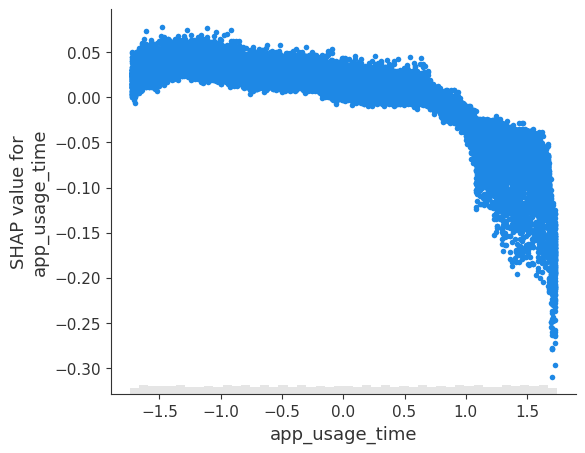

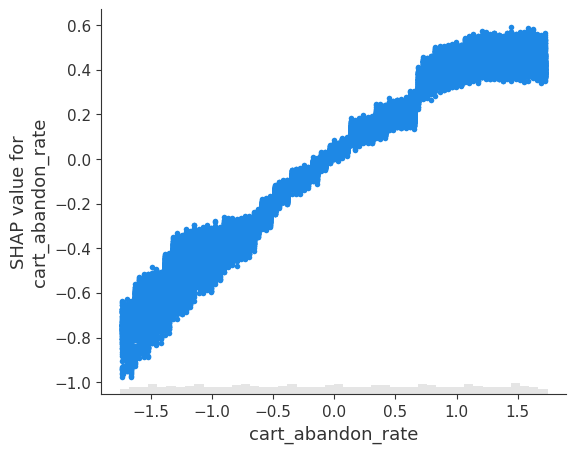

In [26]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test_df)

# Dependence plot for key features
shap.plots.scatter(shap_values[:, "days_since_last_login"])
shap.plots.scatter(shap_values[:, "app_usage_time"])
shap.plots.scatter(shap_values[:, "cart_abandon_rate"])